# Task 3: Real-Time Echocardiogram Video Analysis

Processes each frame of an echocardiogram clip (`0X100F044876B98F90.mp4`) through grayscale conversion, histogram equalization, JET colormapping, color balance, and log/gamma transforms to improve chamber visibility and suppress speckle noise.

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

os.makedirs('output', exist_ok=True)
VIDEO_PATH = 'data/0X100F044876B98F90.mp4'

HAS_DISPLAY = bool(os.environ.get('DISPLAY')) or sys.platform in ('darwin', 'win32')

SHOW_LIVE = True
MAX_SCREENSHOTS = 6

## Define the Per-Frame Processing Pipeline

In [12]:
def process_frame(frame_bgr):
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)

    equalized = cv2.equalizeHist(gray)

    colored = cv2.applyColorMap(equalized, cv2.COLORMAP_JET)

    b, g, r = cv2.split(colored)
    r = np.clip(r.astype(np.float32) * 1.15, 0, 255).astype(np.uint8)
    g = np.clip(g.astype(np.float32) * 0.95, 0, 255).astype(np.uint8)
    b = np.clip(b.astype(np.float32) * 0.90, 0, 255).astype(np.uint8)
    balanced = cv2.merge([b, g, r])

    f = balanced.astype(np.float32) / 255.0
    c_log = 1.0 / np.log(1 + 1.0)
    log_out = np.clip(c_log * np.log(1 + f) * 255, 0, 255).astype(np.uint8)

    gamma = 1.4
    f2 = log_out.astype(np.float32) / 255.0
    gamma_out = np.clip(np.power(f2, gamma) * 255, 0, 255).astype(np.uint8)

    return gamma_out

## Load Video and Inspect Metadata

In [13]:
cap = cv2.VideoCapture(VIDEO_PATH)

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps          = cap.get(cv2.CAP_PROP_FPS)
width        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
duration_sec = total_frames / fps if fps > 0 else 0

print(f'Video file   : {VIDEO_PATH}')
print(f'Resolution   : {width} x {height} px')
print(f'Total frames : {total_frames}')
print(f'Frame rate   : {fps:.2f} fps')
print(f'Duration     : {duration_sec:.2f} seconds')

cap.release()

Video file   : data/0X100F044876B98F90.mp4
Resolution   : 112 x 112 px
Total frames : 221
Frame rate   : 50.00 fps
Duration     : 4.42 seconds


## Step 1: Extract Raw Frame
Extract the first frame as a baseline before any processing.

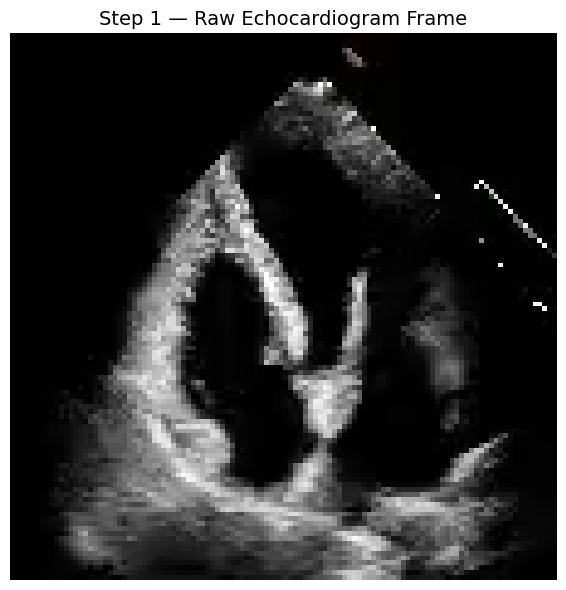

Raw frame shape: (112, 112, 3)


In [14]:
cap = cv2.VideoCapture(VIDEO_PATH)
ret, frame_raw = cap.read()
cap.release()

if not ret:
    raise RuntimeError('Failed to read first frame from video.')

cv2.imwrite('output/01_echo_raw_frame.png', frame_raw)

plt.figure(figsize=(7, 6))
plt.imshow(cv2.cvtColor(frame_raw, cv2.COLOR_BGR2RGB))
plt.title('Step 1 — Raw Echocardiogram Frame', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

print(f'Raw frame shape: {frame_raw.shape}')

## Step 2: Apply Enhancement Pipeline
Run the full per-frame pipeline on the raw frame.

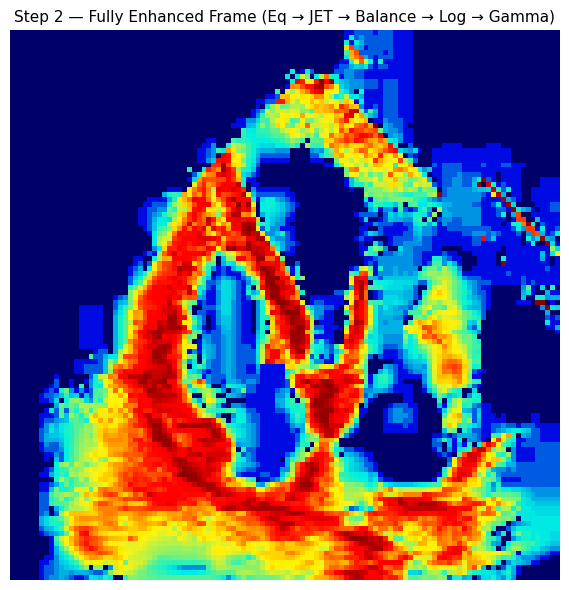

In [15]:
frame_enhanced = process_frame(frame_raw)
cv2.imwrite('output/02_echo_enhanced_frame.png', frame_enhanced)

plt.figure(figsize=(7, 6))
plt.imshow(cv2.cvtColor(frame_enhanced, cv2.COLOR_BGR2RGB))
plt.title('Step 2 — Fully Enhanced Frame (Eq → JET → Balance → Log → Gamma)', fontsize=11)
plt.axis('off')
plt.tight_layout()
plt.show()

## Step 3: Side-by-Side Comparison
Display raw vs. enhanced frames to show the pipeline's impact.

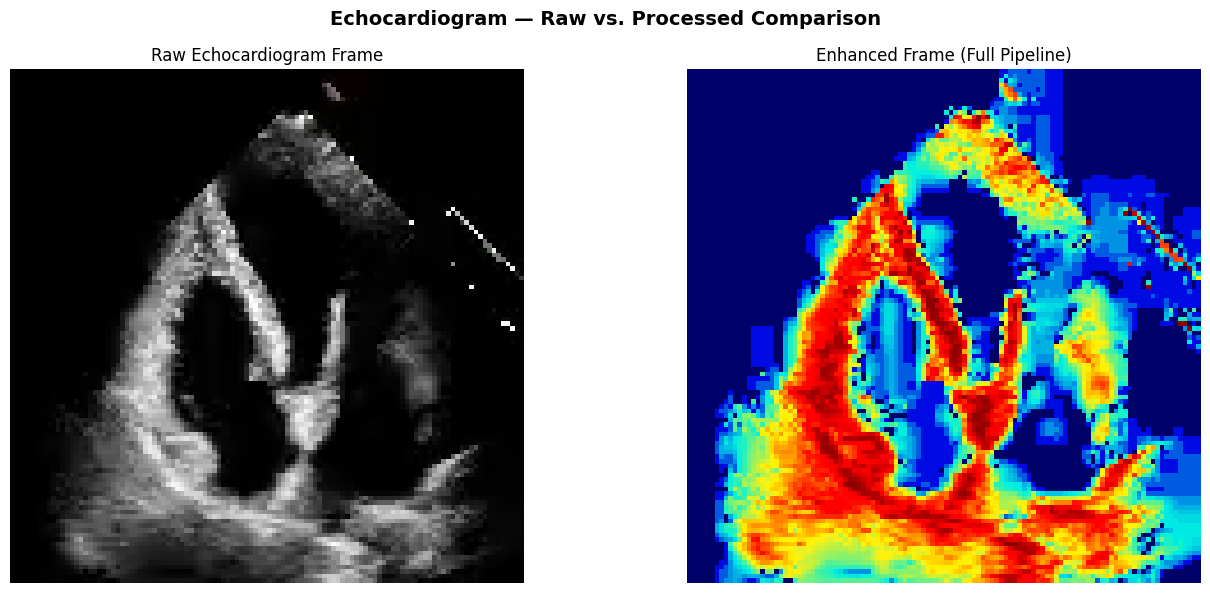

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(cv2.cvtColor(frame_raw,      cv2.COLOR_BGR2RGB))
axes[0].set_title('Raw Echocardiogram Frame', fontsize=12)
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(frame_enhanced, cv2.COLOR_BGR2RGB))
axes[1].set_title('Enhanced Frame (Full Pipeline)', fontsize=12)
axes[1].axis('off')

plt.suptitle('Echocardiogram — Raw vs. Processed Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output/03_echo_side_by_side_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4: Multi-Frame Monitoring Array
Sample four frames across the video and compare raw vs. enhanced in a grid.

Extracted 4 sample frames at positions: [0, 73, 146, 220]


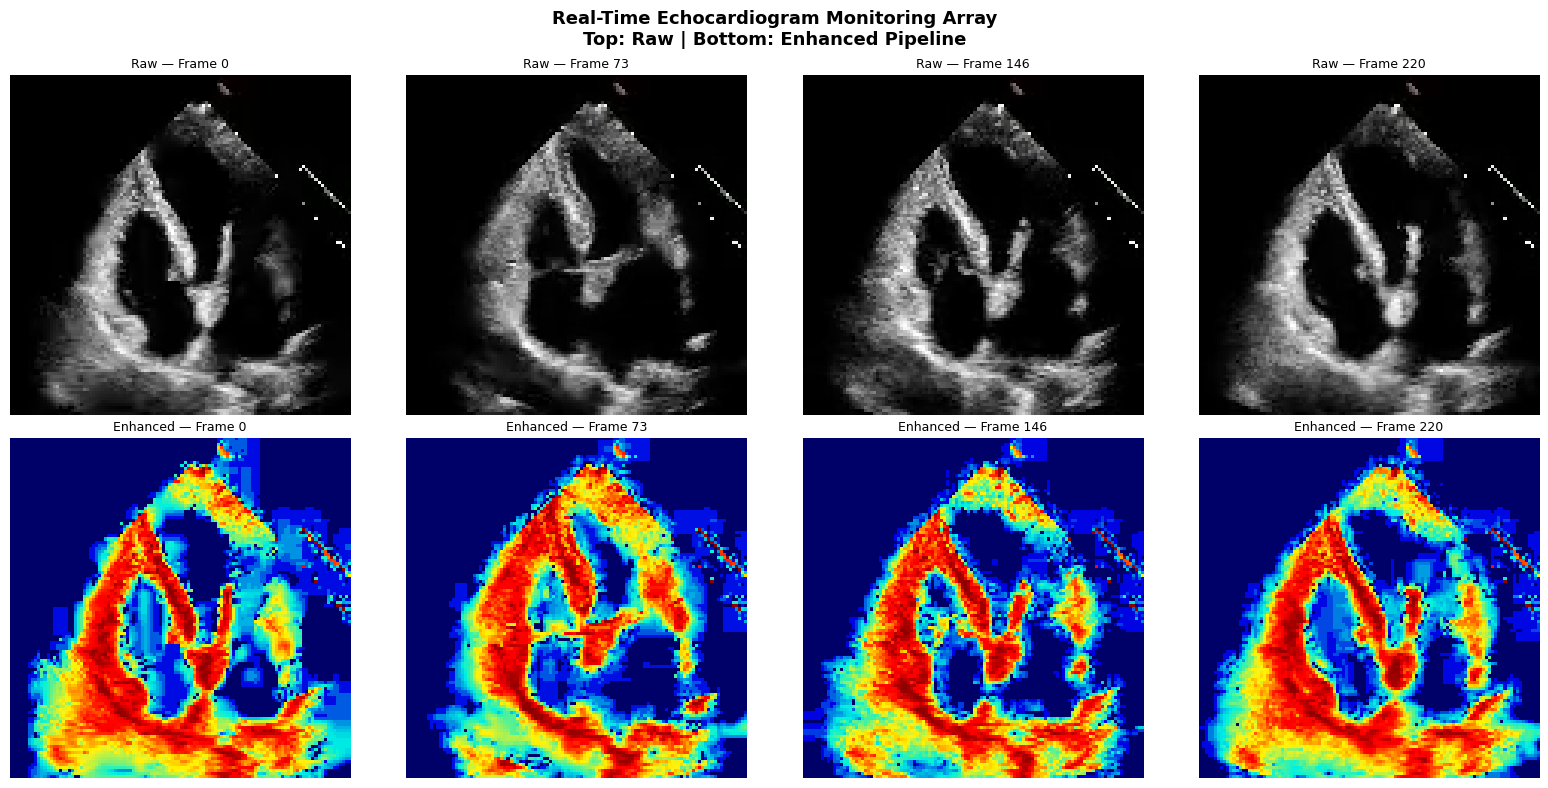

In [17]:
cap = cv2.VideoCapture(VIDEO_PATH)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

num_samples = 4
sample_indices = [int(i * (total_frames - 1) / (num_samples - 1)) for i in range(num_samples)]

raw_frames      = []
enhanced_frames = []

for idx in sample_indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    if ret:
        raw_frames.append(frame)
        enhanced_frames.append(process_frame(frame))

cap.release()

print(f'Extracted {len(raw_frames)} sample frames at positions: {sample_indices}')

n = len(raw_frames)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))

for i in range(n):
    axes[0, i].imshow(cv2.cvtColor(raw_frames[i],      cv2.COLOR_BGR2RGB))
    axes[0, i].set_title(f'Raw — Frame {sample_indices[i]}', fontsize=9)
    axes[0, i].axis('off')

    axes[1, i].imshow(cv2.cvtColor(enhanced_frames[i], cv2.COLOR_BGR2RGB))
    axes[1, i].set_title(f'Enhanced — Frame {sample_indices[i]}', fontsize=9)
    axes[1, i].axis('off')

plt.suptitle('Real-Time Echocardiogram Monitoring Array\nTop: Raw | Bottom: Enhanced Pipeline', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/echo_processed_preview.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5: Real-Time Video Processing Loop
Continuously read every frame with a `while` loop, enhance it, concatenate it with the raw frame, and display live via `cv2.imshow()` — falling back to saved screenshots when no display is available (e.g. headless grading).

In [18]:
cap = cv2.VideoCapture(VIDEO_PATH)

total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
screenshot_interval = max(1, total // MAX_SCREENSHOTS)

frame_idx = 0
saved_screenshots = 0

if SHOW_LIVE and not HAS_DISPLAY:
    print('No display detected; skipping cv2.imshow() and saving screenshots instead.')

while True:
    ret, frame = cap.read()
    if not ret:
        break

    enhanced = process_frame(frame)
    combined = np.hstack([frame, enhanced])

    if SHOW_LIVE and HAS_DISPLAY:
        cv2.imshow('Raw (left) vs Enhanced (right)', combined)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    if frame_idx % screenshot_interval == 0 and saved_screenshots < MAX_SCREENSHOTS:
        cv2.imwrite(f'output/04_live_loop_frame_{frame_idx:04d}.png', combined)
        saved_screenshots += 1

    frame_idx += 1

cap.release()
if HAS_DISPLAY:
    cv2.destroyAllWindows()

print(f'Processed {frame_idx} frames, saved {saved_screenshots} screenshots to output/')

Processed 221 frames, saved 6 screenshots to output/


## Step 6: Preview a Live-Loop Frame
`cv2.imshow` can't render inline in a notebook, so preview one saved side-by-side frame here to confirm the loop worked.

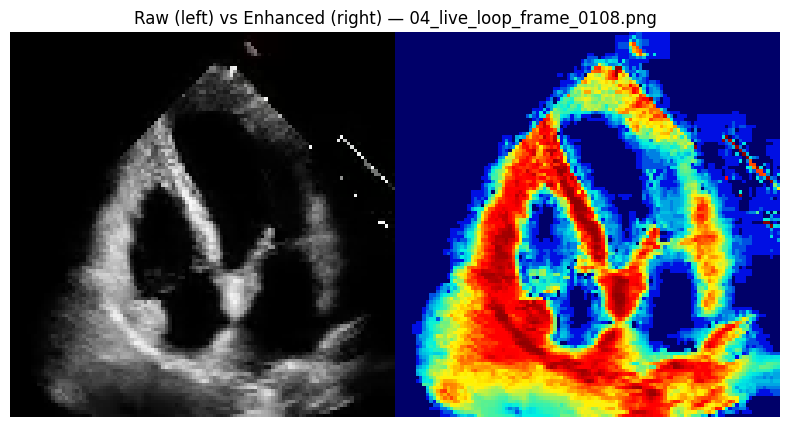

In [19]:
import glob

saved = sorted(glob.glob('output/04_live_loop_frame_*.png'))

preview = cv2.imread(saved[len(saved) // 2])
plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB))
plt.title(f'Raw (left) vs Enhanced (right) — {os.path.basename(saved[len(saved) // 2])}')
plt.axis('off')
plt.show()